In [2]:
from pathlib import Path

DATASET_ROOT = Path("images")

print(DATASET_ROOT.exists())
print((DATASET_ROOT / "train").exists())
print((DATASET_ROOT / "val").exists())
print((DATASET_ROOT / "test").exists())

True
True
True
True


In [3]:
from pathlib import Path

train_path = Path("images/train")

items = list(train_path.iterdir())

print("Number of items:", len(items))

for item in items[:20]:
    print(item)

Number of items: 1472
images/train/adolphe-joseph-thomas-monticelli_an-evening-at-the-paiva.jpg
images/train/adriaen-brouwer_jan-davidszoon-de-heem.jpg
images/train/adriaen-van-de-venne_mans-grief.jpg
images/train/adriaen-van-ostade_the-violinist.jpg
images/train/agnolo-bronzino_alessandro-de-medici.jpg
images/train/agnolo-bronzino_portrait-of-andrea-doria-as-neptune.jpg
images/train/agnolo-bronzino_portrait-of-giovanni-de-medici-1545.jpg
images/train/agnolo-bronzino_portrait-of-laura-battiferri.jpg
images/train/agnolo-bronzino_the-dead-christ-with-the-virgin-and-st-mary-magdalene-1530.jpg
images/train/agnolo-bronzino_venus-cupid-and-envy.jpg
images/train/agostino-carracci_hercules-and-deianira.jpg
images/train/agostino-carracci_religion-of-priapus.jpg
images/train/albert-bloch_cityscape.jpg
images/train/albert-bloch_entombent.jpg
images/train/albert-bloch_lied-i-1914.jpg
images/train/albert-gleizes_football-players-1912.jpg
images/train/alberto-magnelli_maschere-no-1-1909.jpg
images/t

In [4]:
import json

with open("annotations/person_keypoints_train.json", "r") as f:
    data = json.load(f)

print(data.keys())

dict_keys(['info', 'licenses', 'images', 'categories', 'annotations'])


In [5]:
print(data["images"][0])

{'id': 2, 'license': 1, 'width': 349, 'height': 450, 'file_name': 'candido-portinari_retrato-de-maria-1932.jpg', 'metadata': {'wikiart_url': 'https://www.wikiart.org/en/candido-portinari/retrato-de-maria-1932', 'wikiart_image_url': 'https://uploads.wikiart.org/images/candido-portinari/retrato-de-maria-1932.jpg', 'wikiart_style': 'Post Impressionism'}}


In [6]:
import pandas as pd

rows = []

for img in data["images"]:
    rows.append({
        "file_name": img["file_name"],
        "style": img["metadata"]["wikiart_style"]
    })

df = pd.DataFrame(rows)

print(df.head())
print()
print("Number of images:", len(df))
print("Number of styles:", df["style"].nunique())
print()
print(df["style"].value_counts())

                                       file_name                       style
0    candido-portinari_retrato-de-maria-1932.jpg          Post Impressionism
1                      jamie-wyeth_orca-1990.jpg        Contemporary Realism
2   tintoretto_the-birth-of-john-the-baptist.jpg  Mannerism Late Renaissance
3  benjamin-west_portrait-of-henry-middleton.jpg                      Rococo
4    roy-lichtenstein_girl-with-ball-1961(1).jpg                     Pop Art

Number of images: 1472
Number of styles: 22

style
Post Impressionism            75
Mannerism Late Renaissance    75
Pop Art                       75
Rococo                        75
Impressionism                 75
Northern Renaissance          75
Symbolism                     75
Ukiyo e                       75
Realism                       75
Baroque                       75
Romanticism                   75
Expressionism                 75
High Renaissance              75
Naive Art Primitivism         75
Art Nouveau Modern      

In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["style"])

print(df.head())
print()
print("Classes:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, class_name)

                                       file_name                       style  \
0    candido-portinari_retrato-de-maria-1932.jpg          Post Impressionism   
1                      jamie-wyeth_orca-1990.jpg        Contemporary Realism   
2   tintoretto_the-birth-of-john-the-baptist.jpg  Mannerism Late Renaissance   
3  benjamin-west_portrait-of-henry-middleton.jpg                      Rococo   
4    roy-lichtenstein_girl-with-ball-1961(1).jpg                     Pop Art   

   label  
0     16  
1      3  
2     10  
3     18  
4     15  

Classes:
0 Abstract Expressionism
1 Art Nouveau Modern
2 Baroque
3 Contemporary Realism
4 Cubism
5 Early Renaissance
6 Expressionism
7 Fauvism
8 High Renaissance
9 Impressionism
10 Mannerism Late Renaissance
11 Naive Art Primitivism
12 New Realism
13 Northern Renaissance
14 Pointillism
15 Pop Art
16 Post Impressionism
17 Realism
18 Rococo
19 Romanticism
20 Symbolism
21 Ukiyo e


In [8]:
print(df.shape)
df.head()

(1472, 3)


,file_name,style,label
0,candido-portinari_retrato-de-maria-1932.jpg,Post Impressionism,16
1,jamie-wyeth_orca-1990.jpg,Contemporary Realism,3
2,tintoretto_the-birth-of-john-the-baptist.jpg,Mannerism Late Renaissance,10
3,benjamin-west_portrait-of-henry-middleton.jpg,Rococo,18
4,roy-lichtenstein_girl-with-ball-1961(1).jpg,Pop Art,15


In [9]:
from pathlib import Path

IMAGE_DIR = Path("images/train")

df["image_path"] = df["file_name"].apply(
    lambda x: str(IMAGE_DIR / x)
)

print(df[["image_path", "style", "label"]].head())

print("\nFile existence check:")
for p in df["image_path"].head():
    print(Path(p).exists(), p)

                                          image_path  \
0  images/train/candido-portinari_retrato-de-mari...   
1             images/train/jamie-wyeth_orca-1990.jpg   
2  images/train/tintoretto_the-birth-of-john-the-...   
3  images/train/benjamin-west_portrait-of-henry-m...   
4  images/train/roy-lichtenstein_girl-with-ball-1...   

                        style  label  
0          Post Impressionism     16  
1        Contemporary Realism      3  
2  Mannerism Late Renaissance     10  
3                      Rococo     18  
4                     Pop Art     15  

File existence check:
True images/train/candido-portinari_retrato-de-maria-1932.jpg
True images/train/jamie-wyeth_orca-1990.jpg
True images/train/tintoretto_the-birth-of-john-the-baptist.jpg
True images/train/benjamin-west_portrait-of-henry-middleton.jpg
True images/train/roy-lichtenstein_girl-with-ball-1961(1).jpg


In [10]:
from PIL import Image
from torch.utils.data import Dataset

class ArtStyleDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        image_path = self.dataframe.loc[idx, "image_path"]
        label = self.dataframe.loc[idx, "label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
print("Dataset class created.")

Dataset class created.


In [12]:
import torch
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = ArtStyleDataset(df, transform=train_transform)

print("Number of training images:", len(train_dataset))

image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Number of training images: 1472
Image shape: torch.Size([3, 224, 224])
Label: 16


In [13]:
print("Total classes:", len(label_encoder.classes_))

for i, style in enumerate(label_encoder.classes_):
    print(i, "->", style)

Total classes: 22
0 -> Abstract Expressionism
1 -> Art Nouveau Modern
2 -> Baroque
3 -> Contemporary Realism
4 -> Cubism
5 -> Early Renaissance
6 -> Expressionism
7 -> Fauvism
8 -> High Renaissance
9 -> Impressionism
10 -> Mannerism Late Renaissance
11 -> Naive Art Primitivism
12 -> New Realism
13 -> Northern Renaissance
14 -> Pointillism
15 -> Pop Art
16 -> Post Impressionism
17 -> Realism
18 -> Rococo
19 -> Romanticism
20 -> Symbolism
21 -> Ukiyo e


In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Labels:", labels[:10])

Batch image shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])
Labels: tensor([ 5, 10,  1, 21, 16,  6, 16,  2,  3,  1])


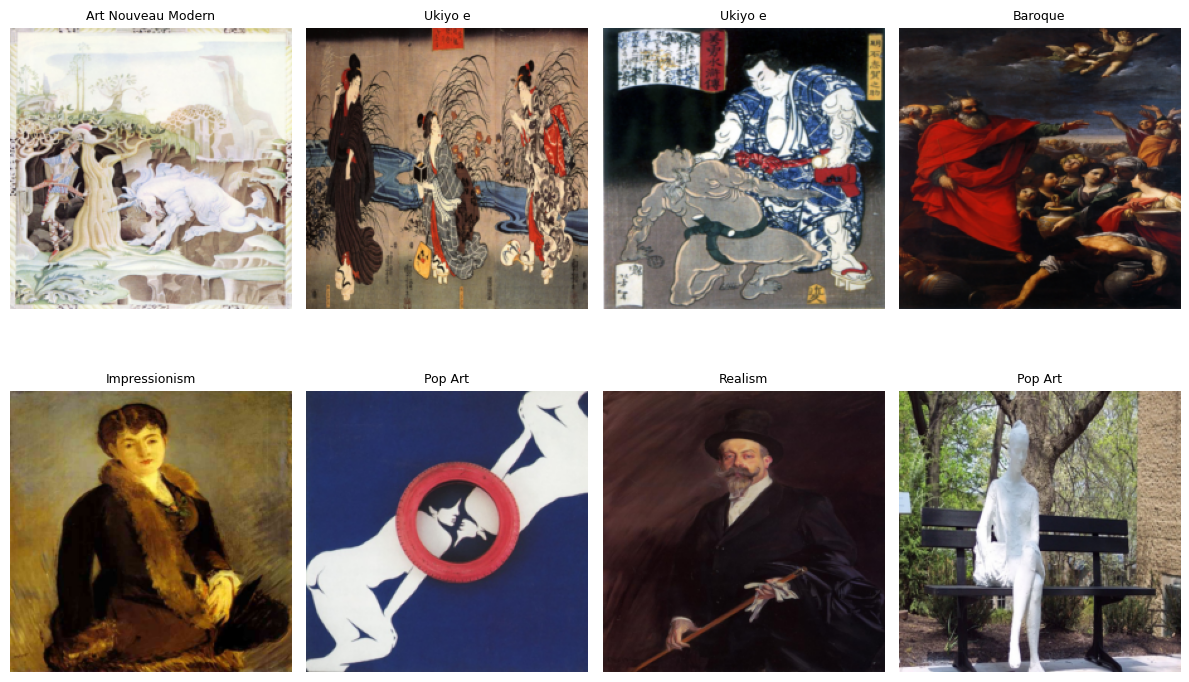

In [15]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 8))

for i in range(8):
    img = images[i].permute(1, 2, 0)
    label_id = labels[i].item()
    style_name = label_encoder.classes_[label_id]

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(style_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

# Load pretrained model
model = resnet50(weights=ResNet50_Weights.DEFAULT)

# Replace final layer
num_classes = len(label_encoder.classes_)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

print(model.fc)

Linear(in_features=2048, out_features=22, bias=True)


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Device:", device)

Device: cuda


In [18]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

PyTorch version: 2.11.0+cu130
CUDA available: True
CUDA version: 13.0
GPU count: 1


In [19]:
torch.cuda.is_available()


True

In [20]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce GTX 1650 Ti


In [21]:
device = torch.device("cuda")
model = model.to(device)

print("Using:", device)

Using: cuda


In [22]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("Ready to train")

Ready to train


In [23]:
model.train()

running_loss = 0.0
correct = 0
total = 0

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

train_loss = running_loss / len(train_loader)
train_acc = 100 * correct / total

print("Train loss:", train_loss)
print("Train accuracy:", train_acc)

Train loss: 2.9544445587241133
Train accuracy: 13.654891304347826


In [24]:
num_epochs = 10

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Accuracy: {100*correct/total:.2f}%"
    )

Epoch 1/10 | Loss: 2.1049 | Accuracy: 56.45%
Epoch 2/10 | Loss: 1.3067 | Accuracy: 76.02%
Epoch 3/10 | Loss: 0.6708 | Accuracy: 90.83%
Epoch 4/10 | Loss: 0.2737 | Accuracy: 97.69%
Epoch 5/10 | Loss: 0.1152 | Accuracy: 98.98%
Epoch 6/10 | Loss: 0.0554 | Accuracy: 99.73%
Epoch 7/10 | Loss: 0.0288 | Accuracy: 99.93%
Epoch 8/10 | Loss: 0.0200 | Accuracy: 99.93%
Epoch 9/10 | Loss: 0.0140 | Accuracy: 100.00%
Epoch 10/10 | Loss: 0.0103 | Accuracy: 100.00%


In [25]:
# Load validation annotations
with open("annotations/person_keypoints_val.json", "r") as f:
    val_data = json.load(f)

val_rows = []

for img in val_data["images"]:
    val_rows.append({
        "file_name": img["file_name"],
        "style": img["metadata"]["wikiart_style"]
    })

val_df = pd.DataFrame(val_rows)

# Use SAME label encoder from training
val_df["label"] = label_encoder.transform(val_df["style"])

VAL_IMAGE_DIR = Path("images/val")
val_df["image_path"] = val_df["file_name"].apply(lambda x: str(VAL_IMAGE_DIR / x))

val_dataset = ArtStyleDataset(val_df, transform=train_transform)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Validation images:", len(val_dataset))

Validation images: 491


In [26]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

val_acc = 100 * correct / total

print("Validation accuracy:", val_acc)

Validation accuracy: 43.17718940936864


In [27]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [28]:
train_dataset = ArtStyleDataset(df, transform=train_transform)
val_dataset = ArtStyleDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

In [29]:
train_dataset = ArtStyleDataset(df, transform=train_transform)
val_dataset = ArtStyleDataset(val_df, transform=val_transform)

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Datasets recreated")

Datasets recreated


In [30]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn

model = resnet50(weights=ResNet50_Weights.DEFAULT)

model.fc = nn.Linear(
    model.fc.in_features,
    len(label_encoder.classes_)
)

model = model.to(device)

print("Fresh model loaded")

Fresh model loaded


In [1]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 10

for epoch in range(num_epochs):
    # training
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # validation
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = outputs.max(1)

            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )
    

NameError: name 'nn' is not defined

In [ ]:
with open("annotations/person_keypoints_test.json", "r") as f:
    test_data = json.load(f)

test_rows = []

for img in test_data["images"]:
    test_rows.append({
        "file_name": img["file_name"],
        "style": img["metadata"]["wikiart_style"]
    })

test_df = pd.DataFrame(test_rows)

test_df["label"] = label_encoder.transform(test_df["style"])

TEST_IMAGE_DIR = Path("images/test")
test_df["image_path"] = test_df["file_name"].apply(lambda x: str(TEST_IMAGE_DIR / x))

test_dataset = ArtStyleDataset(test_df, transform=val_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Test images:", len(test_dataset))

Test images: 491


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100 * correct / total

print("Test accuracy:", test_acc)

Test accuracy: 45.21384928716904


In [ ]:
## confusion matrix
from sklearn.metrics import confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Predictions collected:", len(all_preds))

Predictions collected: 491


In [ ]:
cm = confusion_matrix(all_labels, all_preds)

print(cm.shape)

(22, 22)


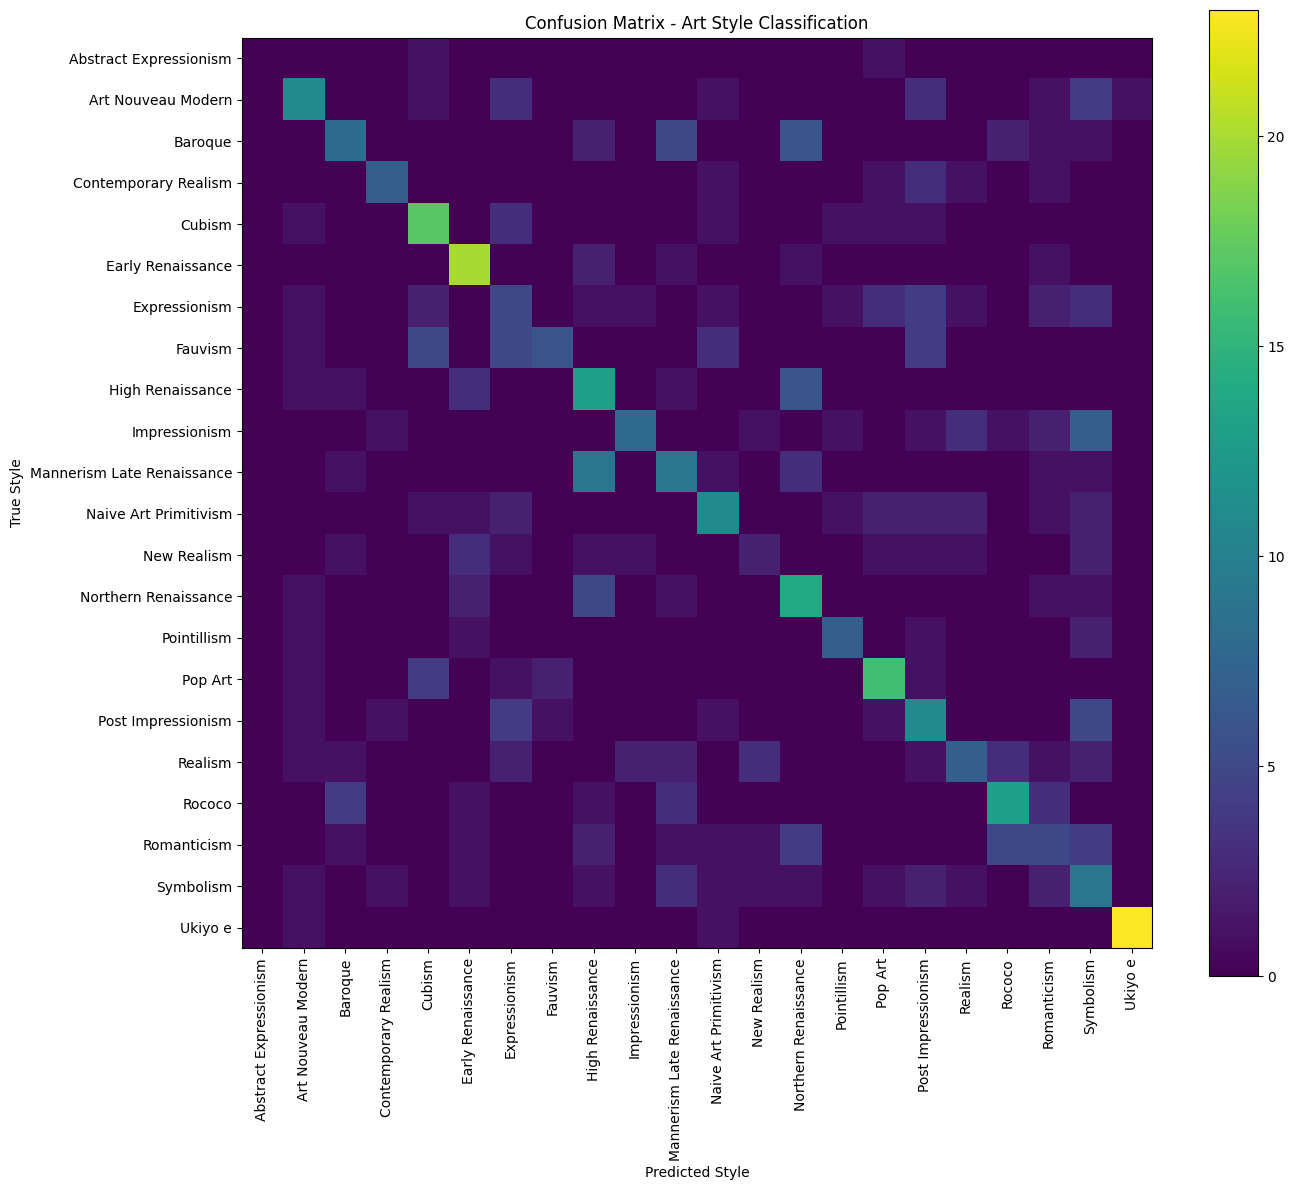

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))

plt.imshow(cm, interpolation='nearest')
plt.colorbar()

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.xlabel("Predicted Style")
plt.ylabel("True Style")
plt.title("Confusion Matrix - Art Style Classification")

plt.tight_layout()
plt.show()

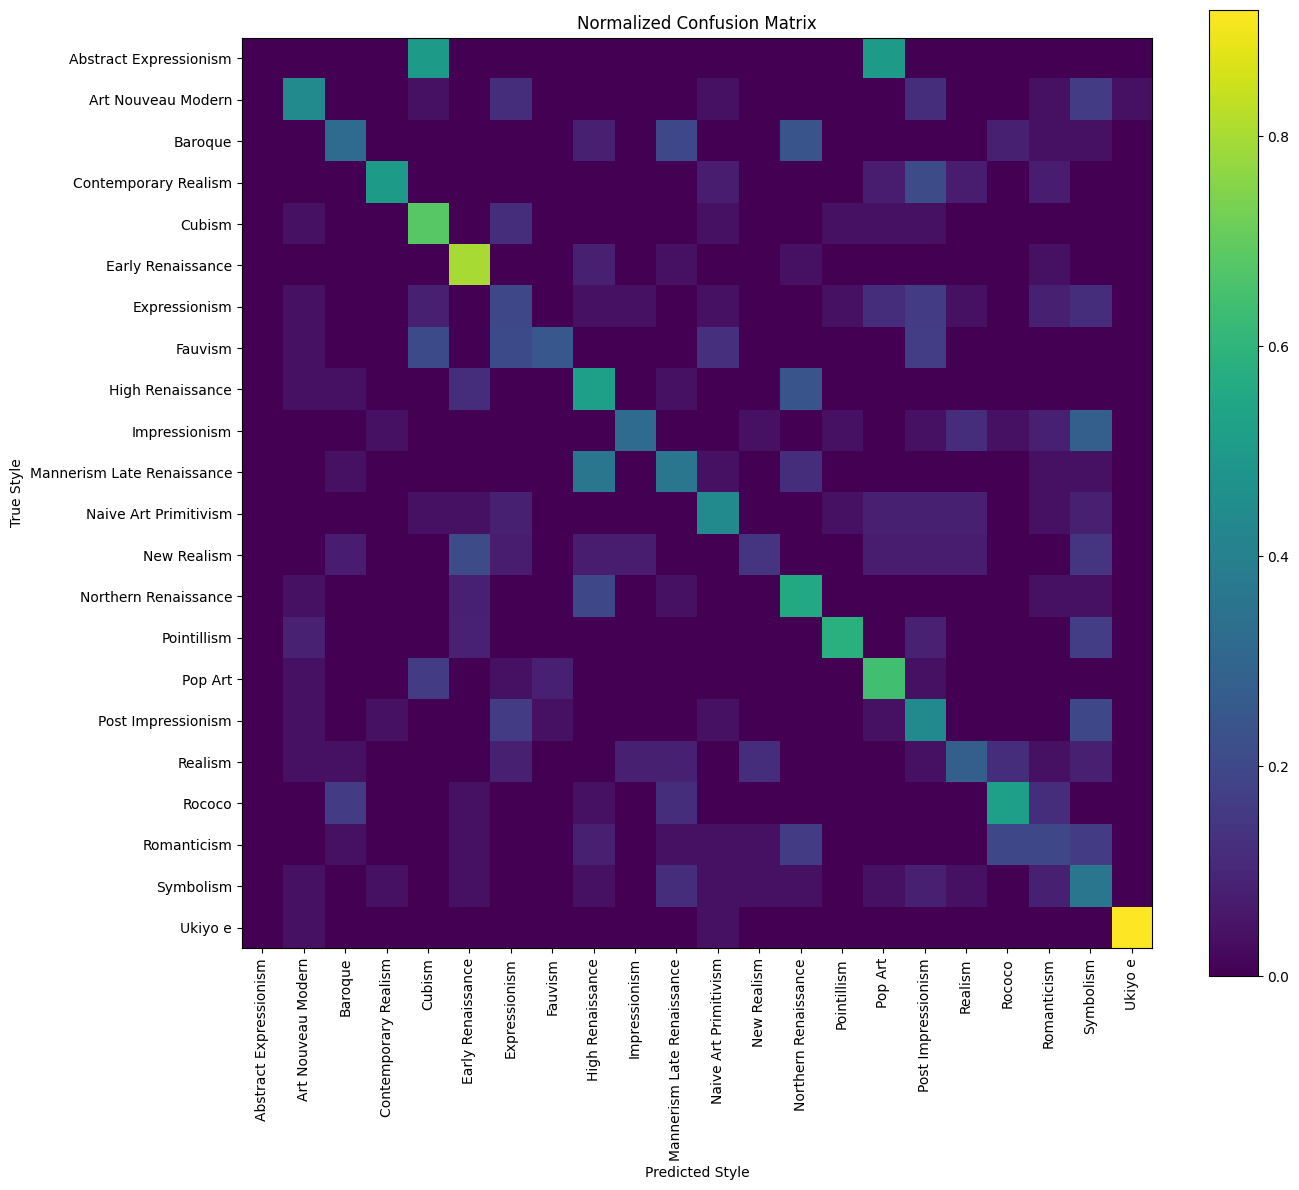

In [ ]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 12))

plt.imshow(cm_norm, interpolation='nearest')
plt.colorbar()

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.xlabel("Predicted Style")
plt.ylabel("True Style")
plt.title("Normalized Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(all_labels, all_preds)

print("="*50)
print(f"Overall Accuracy: {accuracy*100:.2f}%")
print("="*50)

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=label_encoder.classes_
    )
)

Overall Accuracy: 45.21%
                            precision    recall  f1-score   support

    Abstract Expressionism       0.00      0.00      0.00         2
        Art Nouveau Modern       0.50      0.44      0.47        25
                   Baroque       0.47      0.32      0.38        25
      Contemporary Realism       0.70      0.50      0.58        14
                    Cubism       0.55      0.68      0.61        25
         Early Renaissance       0.61      0.80      0.69        25
             Expressionism       0.19      0.20      0.20        25
                   Fauvism       0.67      0.25      0.36        24
          High Renaissance       0.35      0.52      0.42        25
             Impressionism       0.67      0.32      0.43        25
Mannerism Late Renaissance       0.35      0.36      0.35        25
     Naive Art Primitivism       0.48      0.44      0.46        25
               New Realism       0.25      0.14      0.18        14
      Northern Renaiss

/home/chethan/anaconda3/envs/lmuEx1/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/chethan/anaconda3/envs/lmuEx1/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/chethan/anaconda3/envs/lmuEx1/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [ ]:
## result
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(all_labels, all_preds)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy (%): {accuracy*100:.2f}%")

Accuracy: 0.4521
Accuracy (%): 45.21%


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    all_labels,
    all_preds,
    target_names=label_encoder.classes_
)

print(report)

                            precision    recall  f1-score   support

    Abstract Expressionism       0.00      0.00      0.00         2
        Art Nouveau Modern       0.50      0.44      0.47        25
                   Baroque       0.47      0.32      0.38        25
      Contemporary Realism       0.70      0.50      0.58        14
                    Cubism       0.55      0.68      0.61        25
         Early Renaissance       0.61      0.80      0.69        25
             Expressionism       0.19      0.20      0.20        25
                   Fauvism       0.67      0.25      0.36        24
          High Renaissance       0.35      0.52      0.42        25
             Impressionism       0.67      0.32      0.43        25
Mannerism Late Renaissance       0.35      0.36      0.35        25
     Naive Art Primitivism       0.48      0.44      0.46        25
               New Realism       0.25      0.14      0.18        14
      Northern Renaissance       0.40      0.56

/home/chethan/anaconda3/envs/lmuEx1/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/chethan/anaconda3/envs/lmuEx1/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/chethan/anaconda3/envs/lmuEx1/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

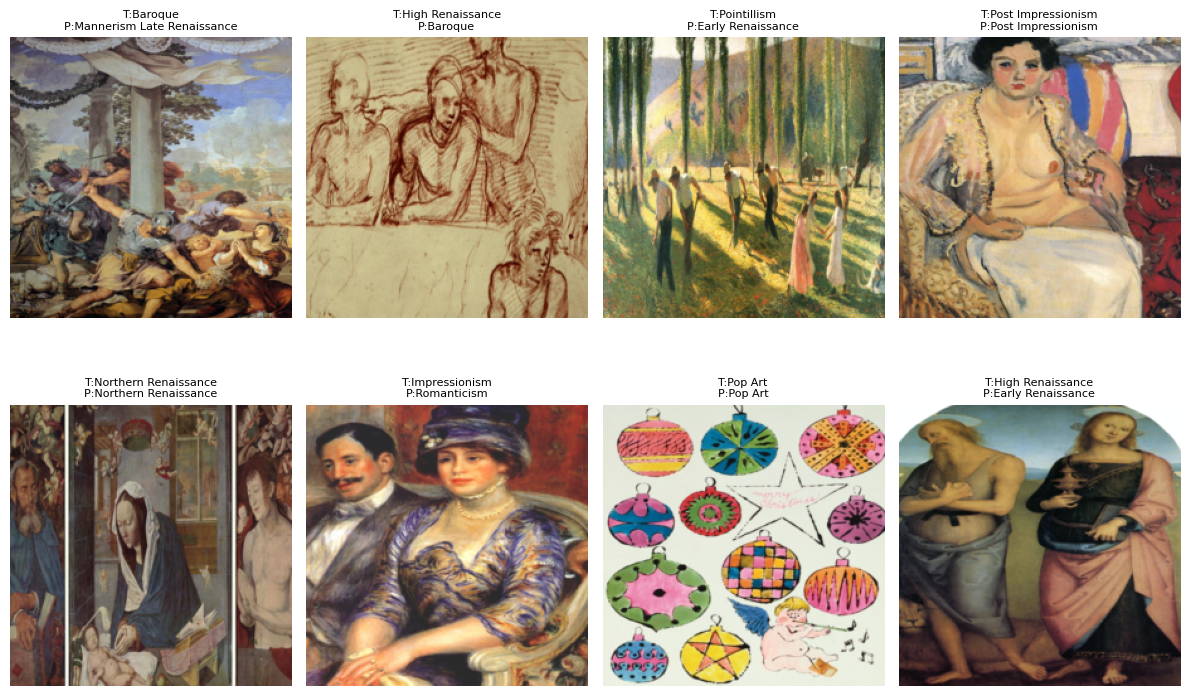

In [ ]:
import random

indices = random.sample(range(len(test_dataset)), 8)

plt.figure(figsize=(12,8))

for i, idx in enumerate(indices):
    image, label = test_dataset[idx]

    with torch.no_grad():
        output = model(image.unsqueeze(0).to(device))
        pred = output.argmax(1).item()

    img = image.permute(1,2,0).numpy()

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    img = img * std + mean
    img = img.clip(0,1)

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(
        f"T:{label_encoder.classes_[label]}\n"
        f"P:{label_encoder.classes_[pred]}",
        fontsize=8
    )
    plt.axis("off")

plt.tight_layout()
plt.show()